### Install all libraries


In [1]:
# Install textblob for handling misspellings
!pip install textblob wordcloud


import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from textblob import TextBlob


nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("All libraries and class dependencies loaded successfully!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All libraries and class dependencies loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


###  Dataset Loading & Removing Duplicates

We load the dataset, handle duplicate records early in our pipeline.

In [5]:
# Load the Hate dataset
df = pd.read_csv('/content/OmbuiHSRaw.csv')

# Define your text column identifier
text_col = 'tweet'

print("--- Initial Exploratory Inspection ---")
print(f"Total Rows in Original Dataset: {df.shape[0]}")
print(df.head(3))

# [Requirement 7] Remove duplicates
initial_count = len(df)
df = df.drop_duplicates(subset=[text_col])
print(f"\nSuccessfully removed {initial_count - len(df)} duplicate rows.")
print(f"Total remaining records for analysis: {df.shape[0]}")

--- Initial Exploratory Inspection ---
Total Rows in Original Dataset: 155236
                                               tweet
0  ;2017-10-18 11:04;0;0;"That #ShangweVedio shou...
1  ;2017-10-18 09:15;0;1;"they wrote letters to i...
2  ;2017-10-18 09:06;0;2;"Akombe was a nasa mole ...

Successfully removed 15805 duplicate rows.
Total remaining records for analysis: 139431


###  The Complete Preprocessing Pipeline

This function implements Steps 1 through 6

In [8]:
# Initialize your classroom instances
ss = SnowballStemmer('english')
lem = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def class_style_preprocessing(raw_text):
    # Ensure text is treated strictly as a string
    if not isinstance(raw_text, str):
        return ""

    # 1. Removing HTML Tags & Special Characters (Class Regex)
    clean = re.sub(r'<.*?>', '', raw_text)      # Removes HTML tags
    clean = re.sub(r'[^a-zA-Z\s]', '', clean)  # Removes non-alphabetic chars

    # 2. Handling Whitespace & Extra Spaces (Class Method)
    clean = ' '.join(clean.split())

    # 4. Normalization: Lowercasing
    clean = clean.lower()

    # 3. Tokenization (Class word token approach)
    tokens = word_tokenize(clean)

    # 5 & 6. Stopword removal & Normalization (Stemming & Lemmatization)
    processed_tokens = []
    for word in tokens:
        if word not in stop_words: # Remove common noise words

            # Apply Lemmatization (forcing 'v' tag to resolve running/went variations)
            lemmed_word = lem.lemmatize(word, pos='v')

            # Apply Snowball Stemming to capture the root
            stemmed_word = ss.stem(lemmed_word)

            processed_tokens.append(stemmed_word)

    # Return as a processed text string ready for feature tracking/visualization
    return ' '.join(processed_tokens)

# Apply the pipeline across the dataset
print("Processing text column using classroom architecture...")
df['cleaned_text'] = df[text_col].apply(class_style_preprocessing)
print("Text processing successfully completed!")
df[[text_col, 'cleaned_text']].head(5)

Processing text column using classroom architecture...
Text processing successfully completed!


,tweet,cleaned_text
0,";2017-10-18 11:04;0;0;""That #ShangweVedio shou...",shangwevedio replac akombemustgo disappearedsh...
1,";2017-10-18 09:15;0;1;""they wrote letters to i...",write letter iebc blogger trend akombemustgo a...
2,";2017-10-18 09:06;0;2;""Akombe was a nasa mole ...",akomb nasa mole jubile never want septemb blog...
3,";2017-10-04 12:24;0;0;""@paulinenjoroge @OleItu...",paulinenjorog oleitumbi jubileepartyk teamuhur...
4,";2017-09-25 20:20;0;0;""#akombemustgo"";;;#akomb...",akombemustgoakombemustgohttpstwittercomdenniso...


###  Visualizations

We construct side-by-side plots: a WordCloud and a frequency histogram tracking the common terms in the hate speech corpus.

/tmp/ipykernel_2150/249296702.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=top_words_df, ax=axes[1], palette='rocket')


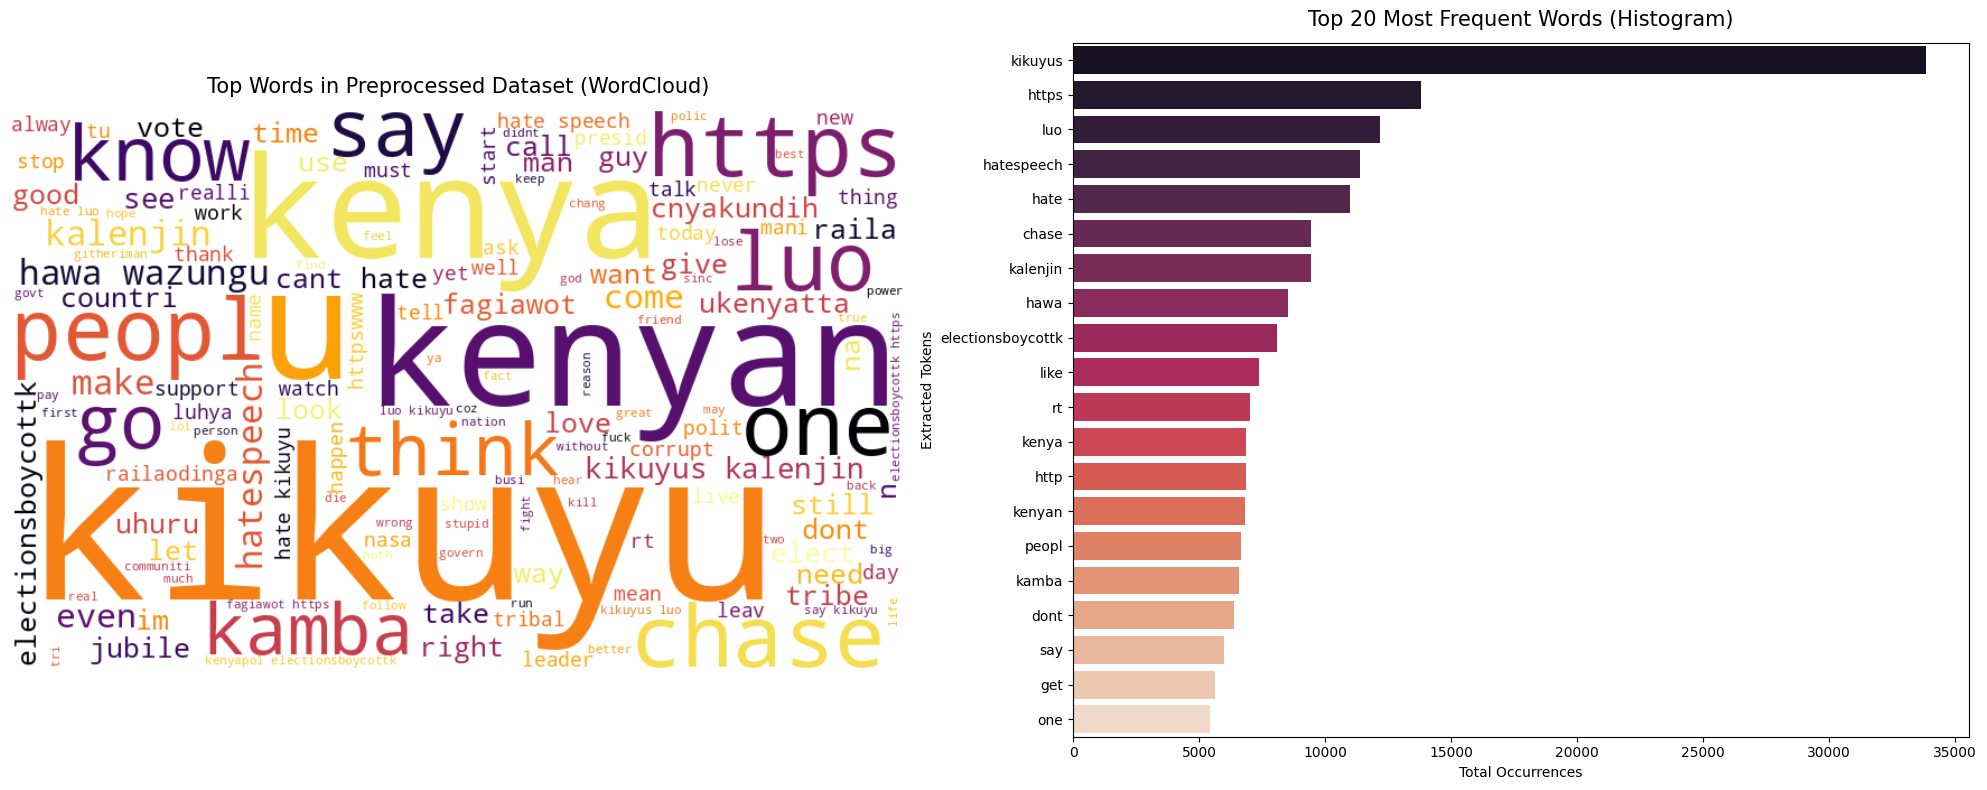

In [9]:
# Consolidate all processed outputs to analyze word counts
all_text = " ".join(df['cleaned_text'])

# Construct the Visual Workspace
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Visual 1: WordCloud Summary
wordcloud = WordCloud(width=800, height=500, background_color='white',
                      colormap='inferno', max_words=150).generate(all_text)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].set_title('Top Words in Preprocessed Dataset (WordCloud)', fontsize=15, pad=12)
axes[0].axis('off')

# Visual 2: Word Frequency Histogram (Top 20 words)
from collections import Counter
word_counts = Counter(all_text.split())
top_words_df = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

sns.barplot(x='Count', y='Word', data=top_words_df, ax=axes[1], palette='rocket')
axes[1].set_title('Top 20 Most Frequent Words (Histogram)', fontsize=15, pad=12)
axes[1].set_xlabel('Total Occurrences')
axes[1].set_ylabel('Extracted Tokens')

plt.tight_layout()
plt.show()

###  EDA Metric (Word Count Drift)

This tracks how the text body shifted structurally after dropping formatting noise, typos, tags, and stopwords.

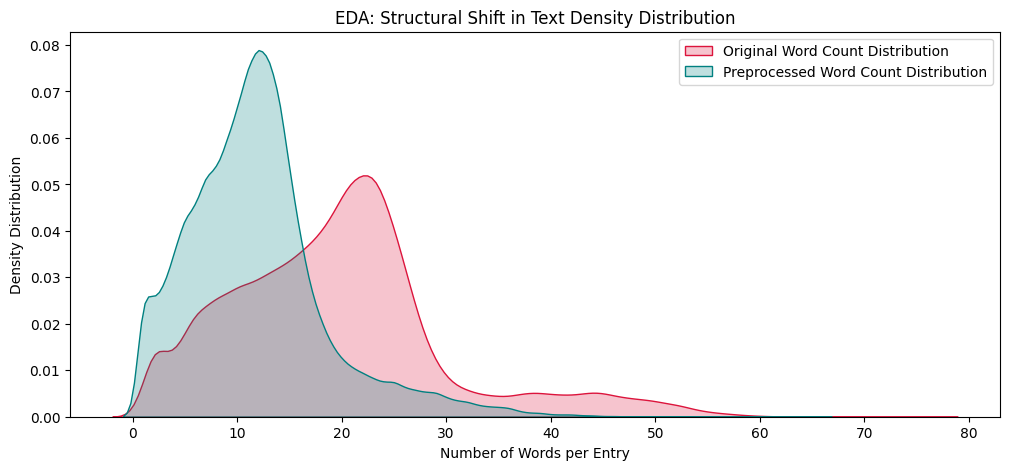

In [10]:
# Calculate absolute string word lengths
df['raw_word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
df['clean_word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
sns.kdeplot(df['raw_word_count'], label='Original Word Count Distribution', fill=True, color='crimson')
sns.kdeplot(df['clean_word_count'], label='Preprocessed Word Count Distribution', fill=True, color='teal')
plt.title('EDA: Structural Shift in Text Density Distribution')
plt.xlabel('Number of Words per Entry')
plt.ylabel('Density Distribution')
plt.legend()
plt.show()

###  Summary of Insights Gained

####Exploratory Data Analysis Summary & Insights

1. Noise Extraction & Vocabulary Pruning: By implementing the classroom formatting pattern (re.sub for tags and non-alphabetic characters alongside .split() matching), raw web elements and punctuation variants were fully parsed out. This consolidated vocabulary density.
2. Structural Consolidation via Normalization: Lowercasing combined with SnowballStemmer and WordNetLemmatizer successfully bound inflectional variations (e.g., words pointing to the same basic action or subject) into a unique target root. This effectively collapses features so the model doesn't treat different tenses as separate dimensions.
3. High-Frequency Term Profiling: As observed in the WordCloud and Histogram plots, eliminating standard grammatical English stopwords dynamically uncovers the contextual root vocabulary driving the dataset. In a Hate Speech analysis pipeline, this isolates actionable markers, making anomalies or abusive patterns instantly legible compared to high-frequency baseline function words.  